# PHA–enzyme distances and contacts
Find which enzyme residues stay close to the whole PHA molecule. Select the **ipha_clean** kernel and run the six steps below in order.

## 1. Set the input and output paths
Edit the paths below for your system. The **TPR** provides atom and residue information; the **XTC** provides the trajectory. For this system, the NPT file is named `step6.2_npt.tpr`.

Each run creates a new folder inside `OUTPUT_DIR`. These notebook settings do not edit the terminal YAML.

In [1]:
from pathlib import Path

PROJECT_DIR = Path("/Users/k20098771/opt/iPHASimulator_v2")
INPUT_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs")

TPR_PATH = INPUT_DIR / "step6.2_npt.tpr"
TRAJECTORY_PATH = INPUT_DIR / "production_combined_1us.xtc"
OUTPUT_DIR = PROJECT_DIR / "examples/output/enzyme_contacts"

print("Topology (.tpr):", TPR_PATH)
print("Trajectory (.xtc):", TRAJECTORY_PATH)
print("Output folder:", OUTPUT_DIR)

Topology (.tpr): /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
Trajectory (.xtc): /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_1us.xtc
Output folder: /Users/k20098771/opt/iPHASimulator_v2/examples/output/enzyme_contacts


## 2. Choose the time window and selections
Start with a **31-frame preview** spread across your chosen window. Set `PREVIEW_FRAMES = None` for the full analysis. `END_NS = None` uses the actual end; `SAMPLE_INTERVAL_NS = None` uses every stored frame before preview sampling. No initial period is discarded automatically.

Both modes exclude hydrogen. Side-chain mode also excludes backbone atoms; glycine side chains remain unavailable. The PHA selection below was checked for this system—review it when changing inputs.

In [2]:
START_NS = 0.0
END_NS = None
SAMPLE_INTERVAL_NS = None  # For example, 1.0 samples every 1 ns.
PREVIEW_FRAMES = 31        # None = full analysis of the selected window.

PROTEIN_SELECTION = "protein"
PHA_SELECTION = "resname LIG and segid seg_1_LIG"
MODES = ("all_heavy", "sidechain_heavy")
PRIMARY_CUTOFF_A = 4.5     # The workflow also reports 4.0 and 5.0 Å.

## 3. Check your inputs
This shows the available times and selected atom counts. Use one matching TPR and the original production XTC with its periodic box. The calculation reads times from the trajectory, rather than its filename.

In [3]:
from dataclasses import replace
import sys

import pandas as pd
from IPython.display import Image, display

if not (PROJECT_DIR / "src/iphasimulator/analysis_contacts.py").is_file():
    raise FileNotFoundError("Check PROJECT_DIR in step 1: the analysis module was not found.")
if str(PROJECT_DIR / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR / "src"))

from iphasimulator.analysis_contacts import (
    load_config, open_universe, select_atoms, run_contacts,
    load_distances, summarise, plot_contacts,
)

if TPR_PATH.suffix.lower() != ".tpr":
    raise ValueError("TPR_PATH must be a matching .tpr file, such as step6.2_npt.tpr.")
for path in (TPR_PATH, TRAJECTORY_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"Check the input paths in step 1: {path}")

# Reuse the original configuration; override paths/settings for this notebook only.
config = replace(
    load_config(PROJECT_DIR / "examples/enzyme_contacts_GK13_P3HO_4.yaml"),
    topology=TPR_PATH, trajectory=TRAJECTORY_PATH, output_root=OUTPUT_DIR,
    label=INPUT_DIR.name.removesuffix("_gromacs"),
    protein_selection=PROTEIN_SELECTION, pha_selection=PHA_SELECTION,
    start_ns=START_NS, end_ns=END_NS, sample_interval_ns=SAMPLE_INTERVAL_NS,
    preview_frames=PREVIEW_FRAMES, modes=MODES, primary_cutoff_A=PRIMARY_CUTOFF_A,
)
config.validate()

with open_universe(config.topology, config.trajectory) as universe:
    selections = select_atoms(universe, config.protein_selection, config.pha_selection)
    first_ns = universe.trajectory[0].time / 1000
    last_ns = universe.trajectory[-1].time / 1000
    print(f"Available: {first_ns:g}–{last_ns:g} ns; {len(universe.trajectory):,} frames")
    print(f"Matching atom counts: {universe.atoms.n_atoms:,} topology / {universe.trajectory.n_atoms:,} trajectory")
    print(f"Protein: {len(selections.residues)} residues")
    for mode in config.modes:
        counts = selections.counts[mode]
        print(f"  {mode}: {counts.sum()} heavy atoms; {(counts == 0).sum()} unavailable residues")
    print(f"PHA: {len(selections.pha)} heavy atoms; {selections.pha.residues}")
print("Run:", f"up to {PREVIEW_FRAMES} preview frames" if PREVIEW_FRAMES is not None else "full selected window")

Available: 0–1480.5 ns; 14,806 frames
Matching atom counts: 137,360 topology / 137,360 trajectory
Protein: 245 residues
  all_heavy: 1898 heavy atoms; 0 unavailable residues
  sidechain_heavy: 917 heavy atoms; 25 unavailable residues
PHA: 41 heavy atoms; <ResidueGroup [<Residue LIG, 246>]>
Run: up to 31 preview frames


## 4. Run the analysis
This checks timestamps and boxes, calculates distances and contacts, then saves plots and data. Even a preview reads the whole XTC once for validation.

Contact percentage = **100 × frames with distance < cutoff / analysed frames**. These sampled frames can be correlated.

In [4]:
RUN_DIR = run_contacts(config)
saved = load_distances(RUN_DIR / "distances.npz")
print(f"Analysed: {len(saved.times_ns):,} frames, {saved.times_ns[0]:g}–{saved.times_ns[-1]:g} ns")
print("All results:", RUN_DIR)

Run directory: /Users/k20098771/opt/iPHASimulator_v2/examples/output/enzyme_contacts/20260907T153550_168062Z_preview_0a92011c
Protein: 245 residues, 1898 heavy atoms; PHA: 41 heavy atoms
Inspecting timestamps/boxes: 1/14806 frames
Inspecting timestamps/boxes: 1001/14806 frames
Inspecting timestamps/boxes: 2001/14806 frames
Inspecting timestamps/boxes: 3001/14806 frames
Inspecting timestamps/boxes: 4001/14806 frames
Inspecting timestamps/boxes: 5001/14806 frames
Inspecting timestamps/boxes: 6001/14806 frames
Inspecting timestamps/boxes: 7001/14806 frames
Inspecting timestamps/boxes: 8001/14806 frames
Inspecting timestamps/boxes: 9001/14806 frames
Inspecting timestamps/boxes: 10001/14806 frames
Inspecting timestamps/boxes: 11001/14806 frames
Inspecting timestamps/boxes: 12001/14806 frames
Inspecting timestamps/boxes: 13001/14806 frames
Inspecting timestamps/boxes: 14001/14806 frames
Inspecting timestamps/boxes: 14806/14806 frames
PREVIEW: 31 frames, [0.0, 1480.5] ns; available 0.0–1480.5

## 5. View the plots and closest residues
Heatmaps show minimum distance in **Å** over time in **ns**. Profiles show contact occupancy from **0–100%**. Grey means unavailable; sparse preview columns represent sampled frames.

The four plots are displayed here and saved as PNGs in `RUN_DIR`. The tables list the ten highest contact percentages; the CSV contains every residue. These are proximity measurements, not binding affinity or proof of catalytic activity.

All enzyme heavy atoms
Enzyme side-chain heavy atoms
Plots: /Users/k20098771/opt/iPHASimulator_v2/examples/output/enzyme_contacts/20260907T153550_168062Z_preview_0a92011c
All residues: /Users/k20098771/opt/iPHASimulator_v2/examples/output/enzyme_contacts/20260907T153550_168062Z_preview_0a92011c/residue_summary.csv
Saved distances: /Users/k20098771/opt/iPHASimulator_v2/examples/output/enzyme_contacts/20260907T153550_168062Z_preview_0a92011c/distances.npz


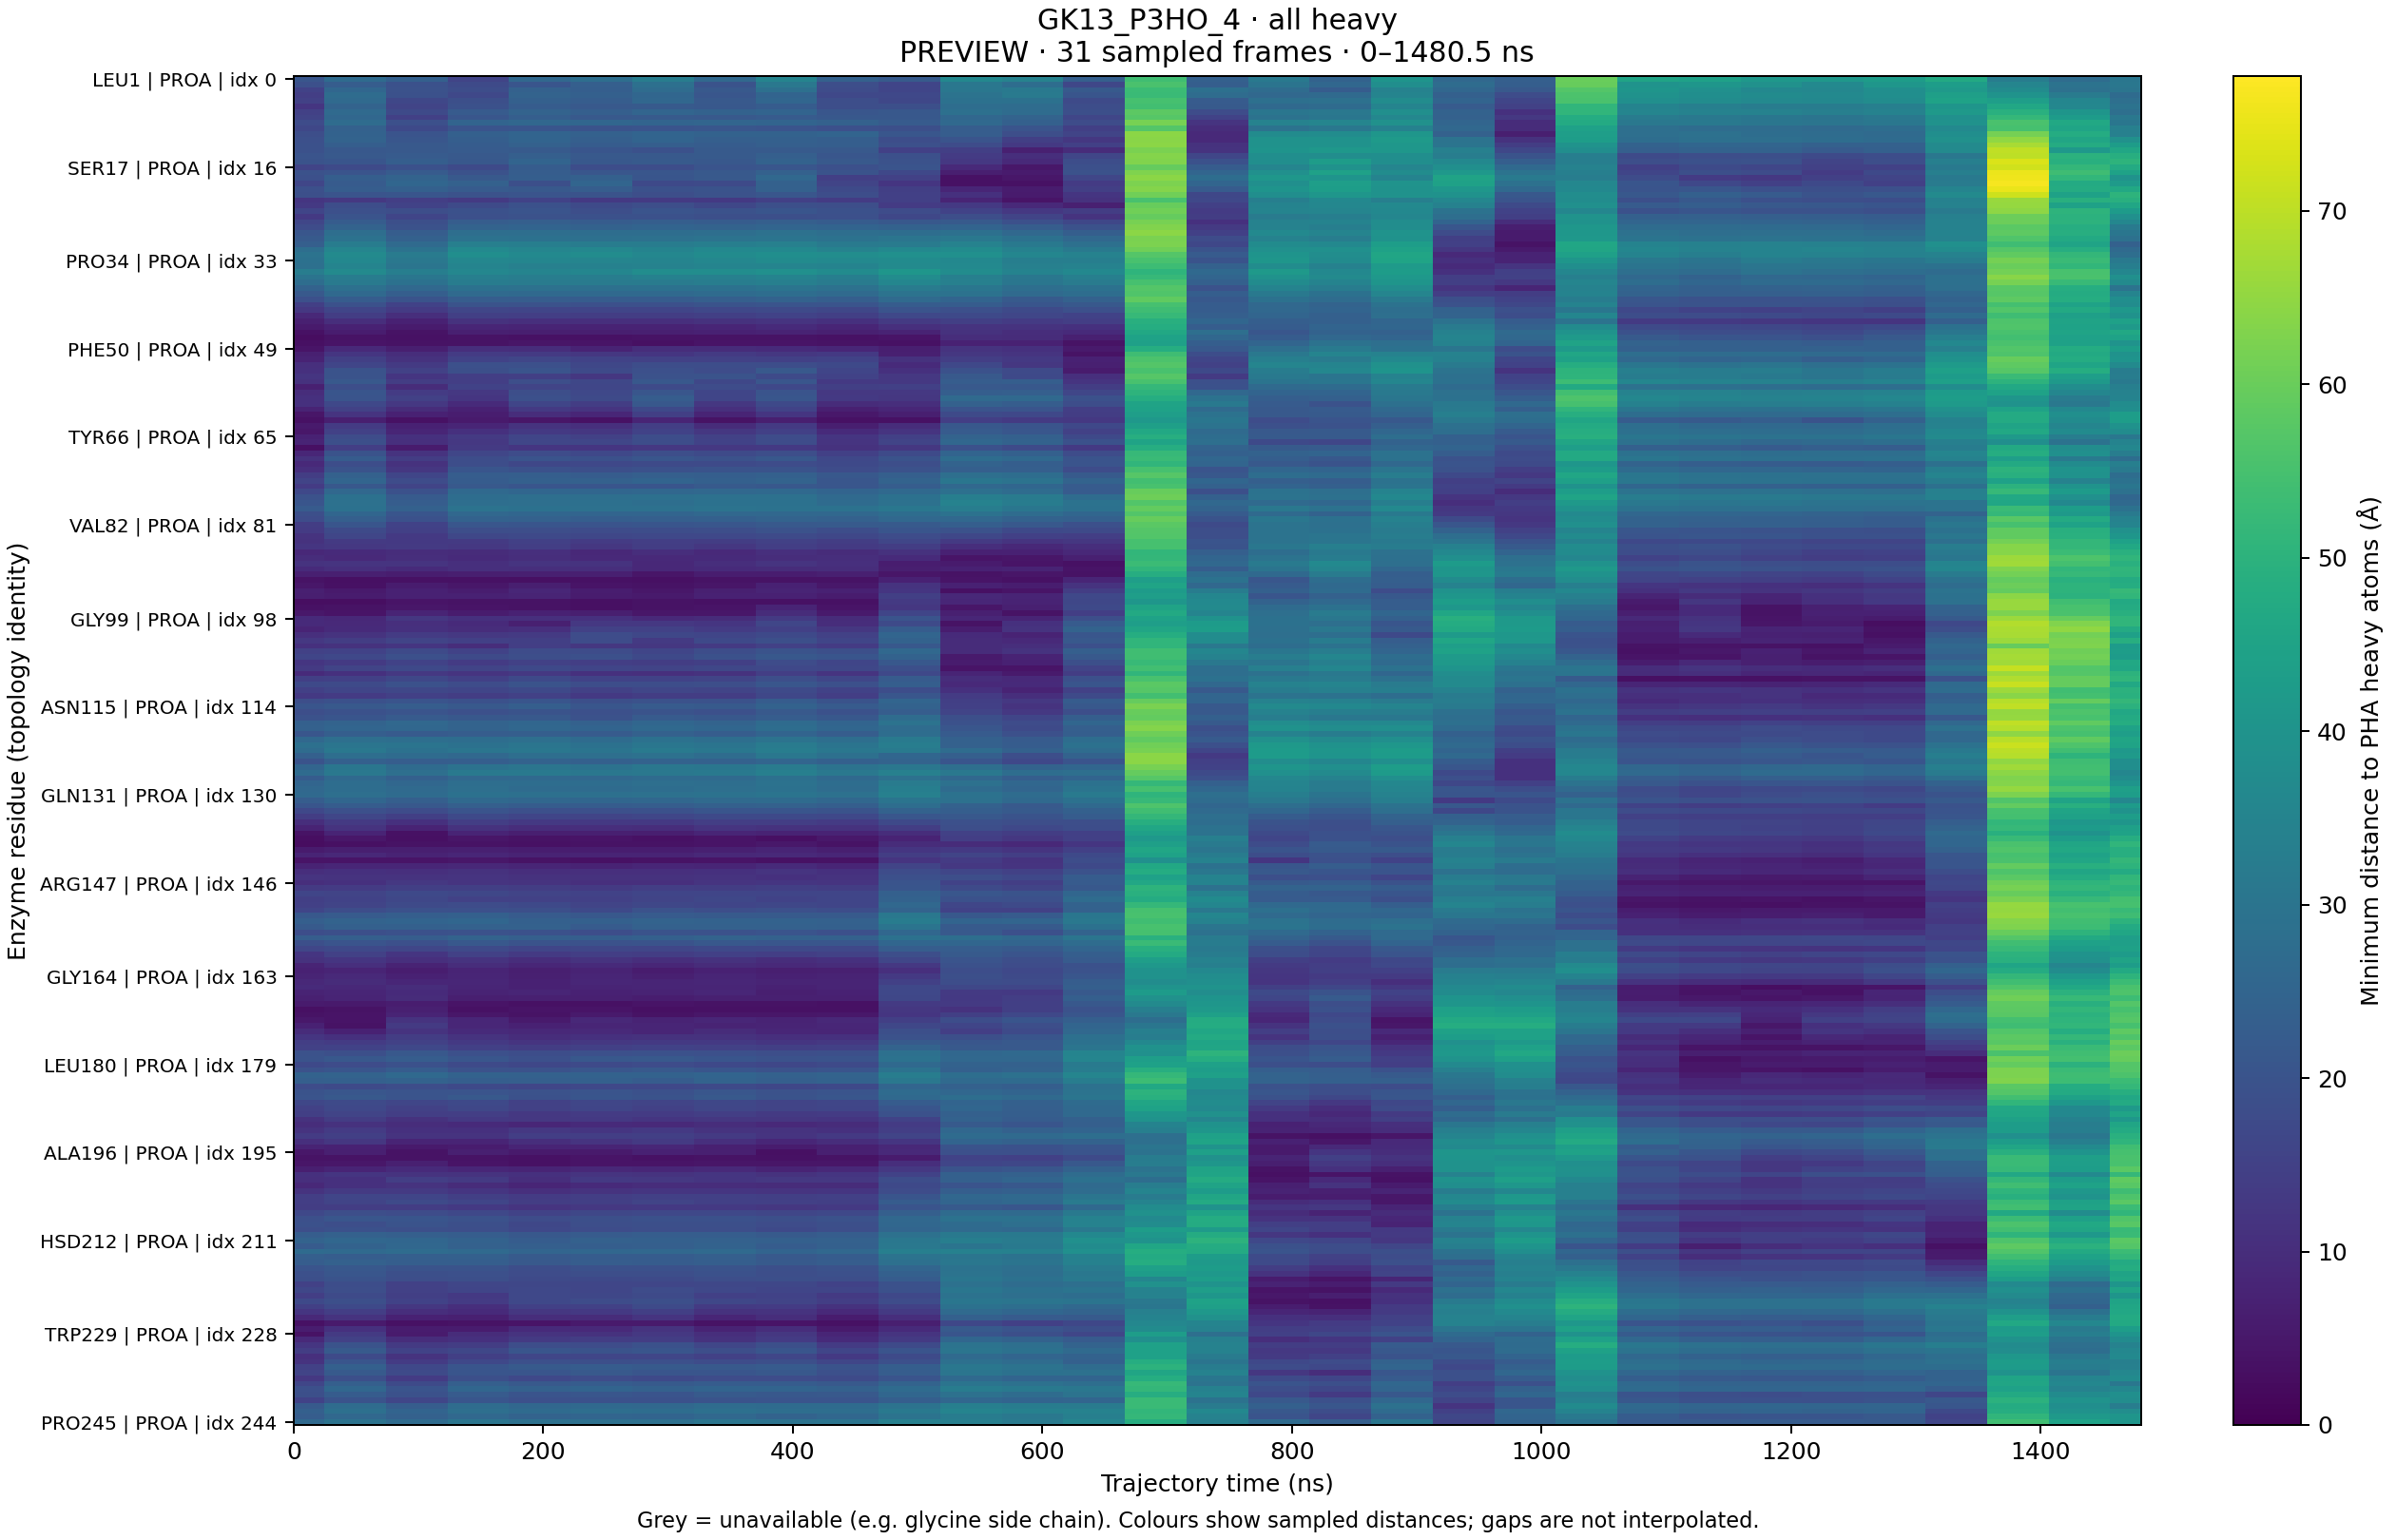

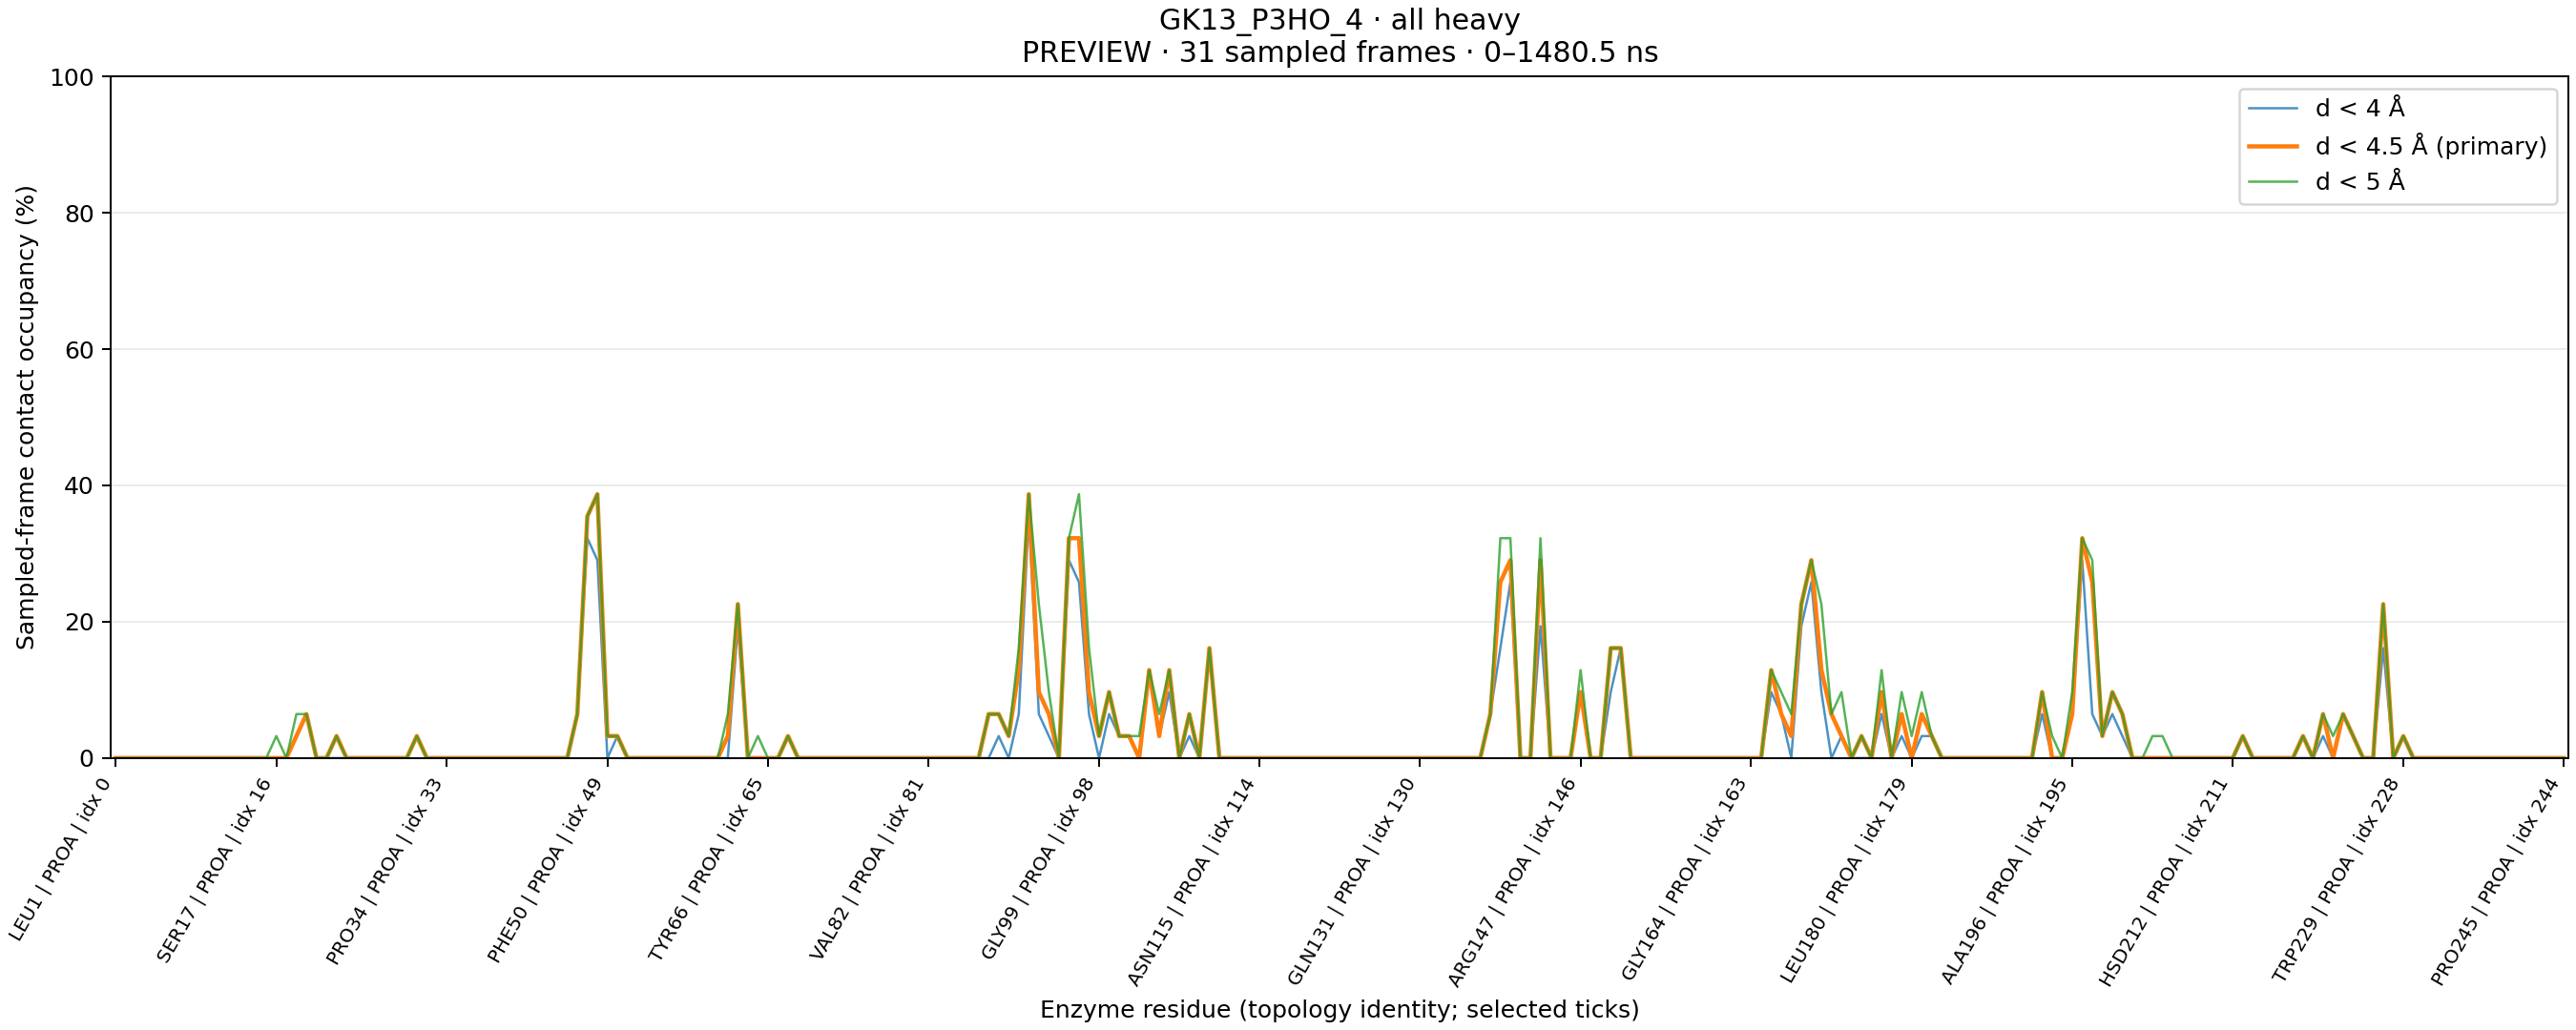

,Residue,Selected atoms,Mean distance (Å),Median distance (Å),Contact below 4.5 Å (%)
0,PHE49 | PROA | idx 48,11,19.57,22.95,38.71
1,PHE92 | PROA | idx 91,11,18.18,14.45,38.71
2,SER48 | PROA | idx 47,6,19.10,20.25,35.48
3,VAL197 | PROA | idx 196,7,18.89,14.61,32.26
4,ILE97 | PROA | idx 96,8,18.51,7.70,32.26
5,ASN96 | PROA | idx 95,8,18.97,12.19,32.26
6,SER140 | PROA | idx 139,6,17.77,12.09,29.03
7,SER170 | PROA | idx 169,6,18.65,11.19,29.03
8,TYR143 | PROA | idx 142,12,16.86,11.41,29.03
9,VAL198 | PROA | idx 197,7,18.68,12.90,25.81


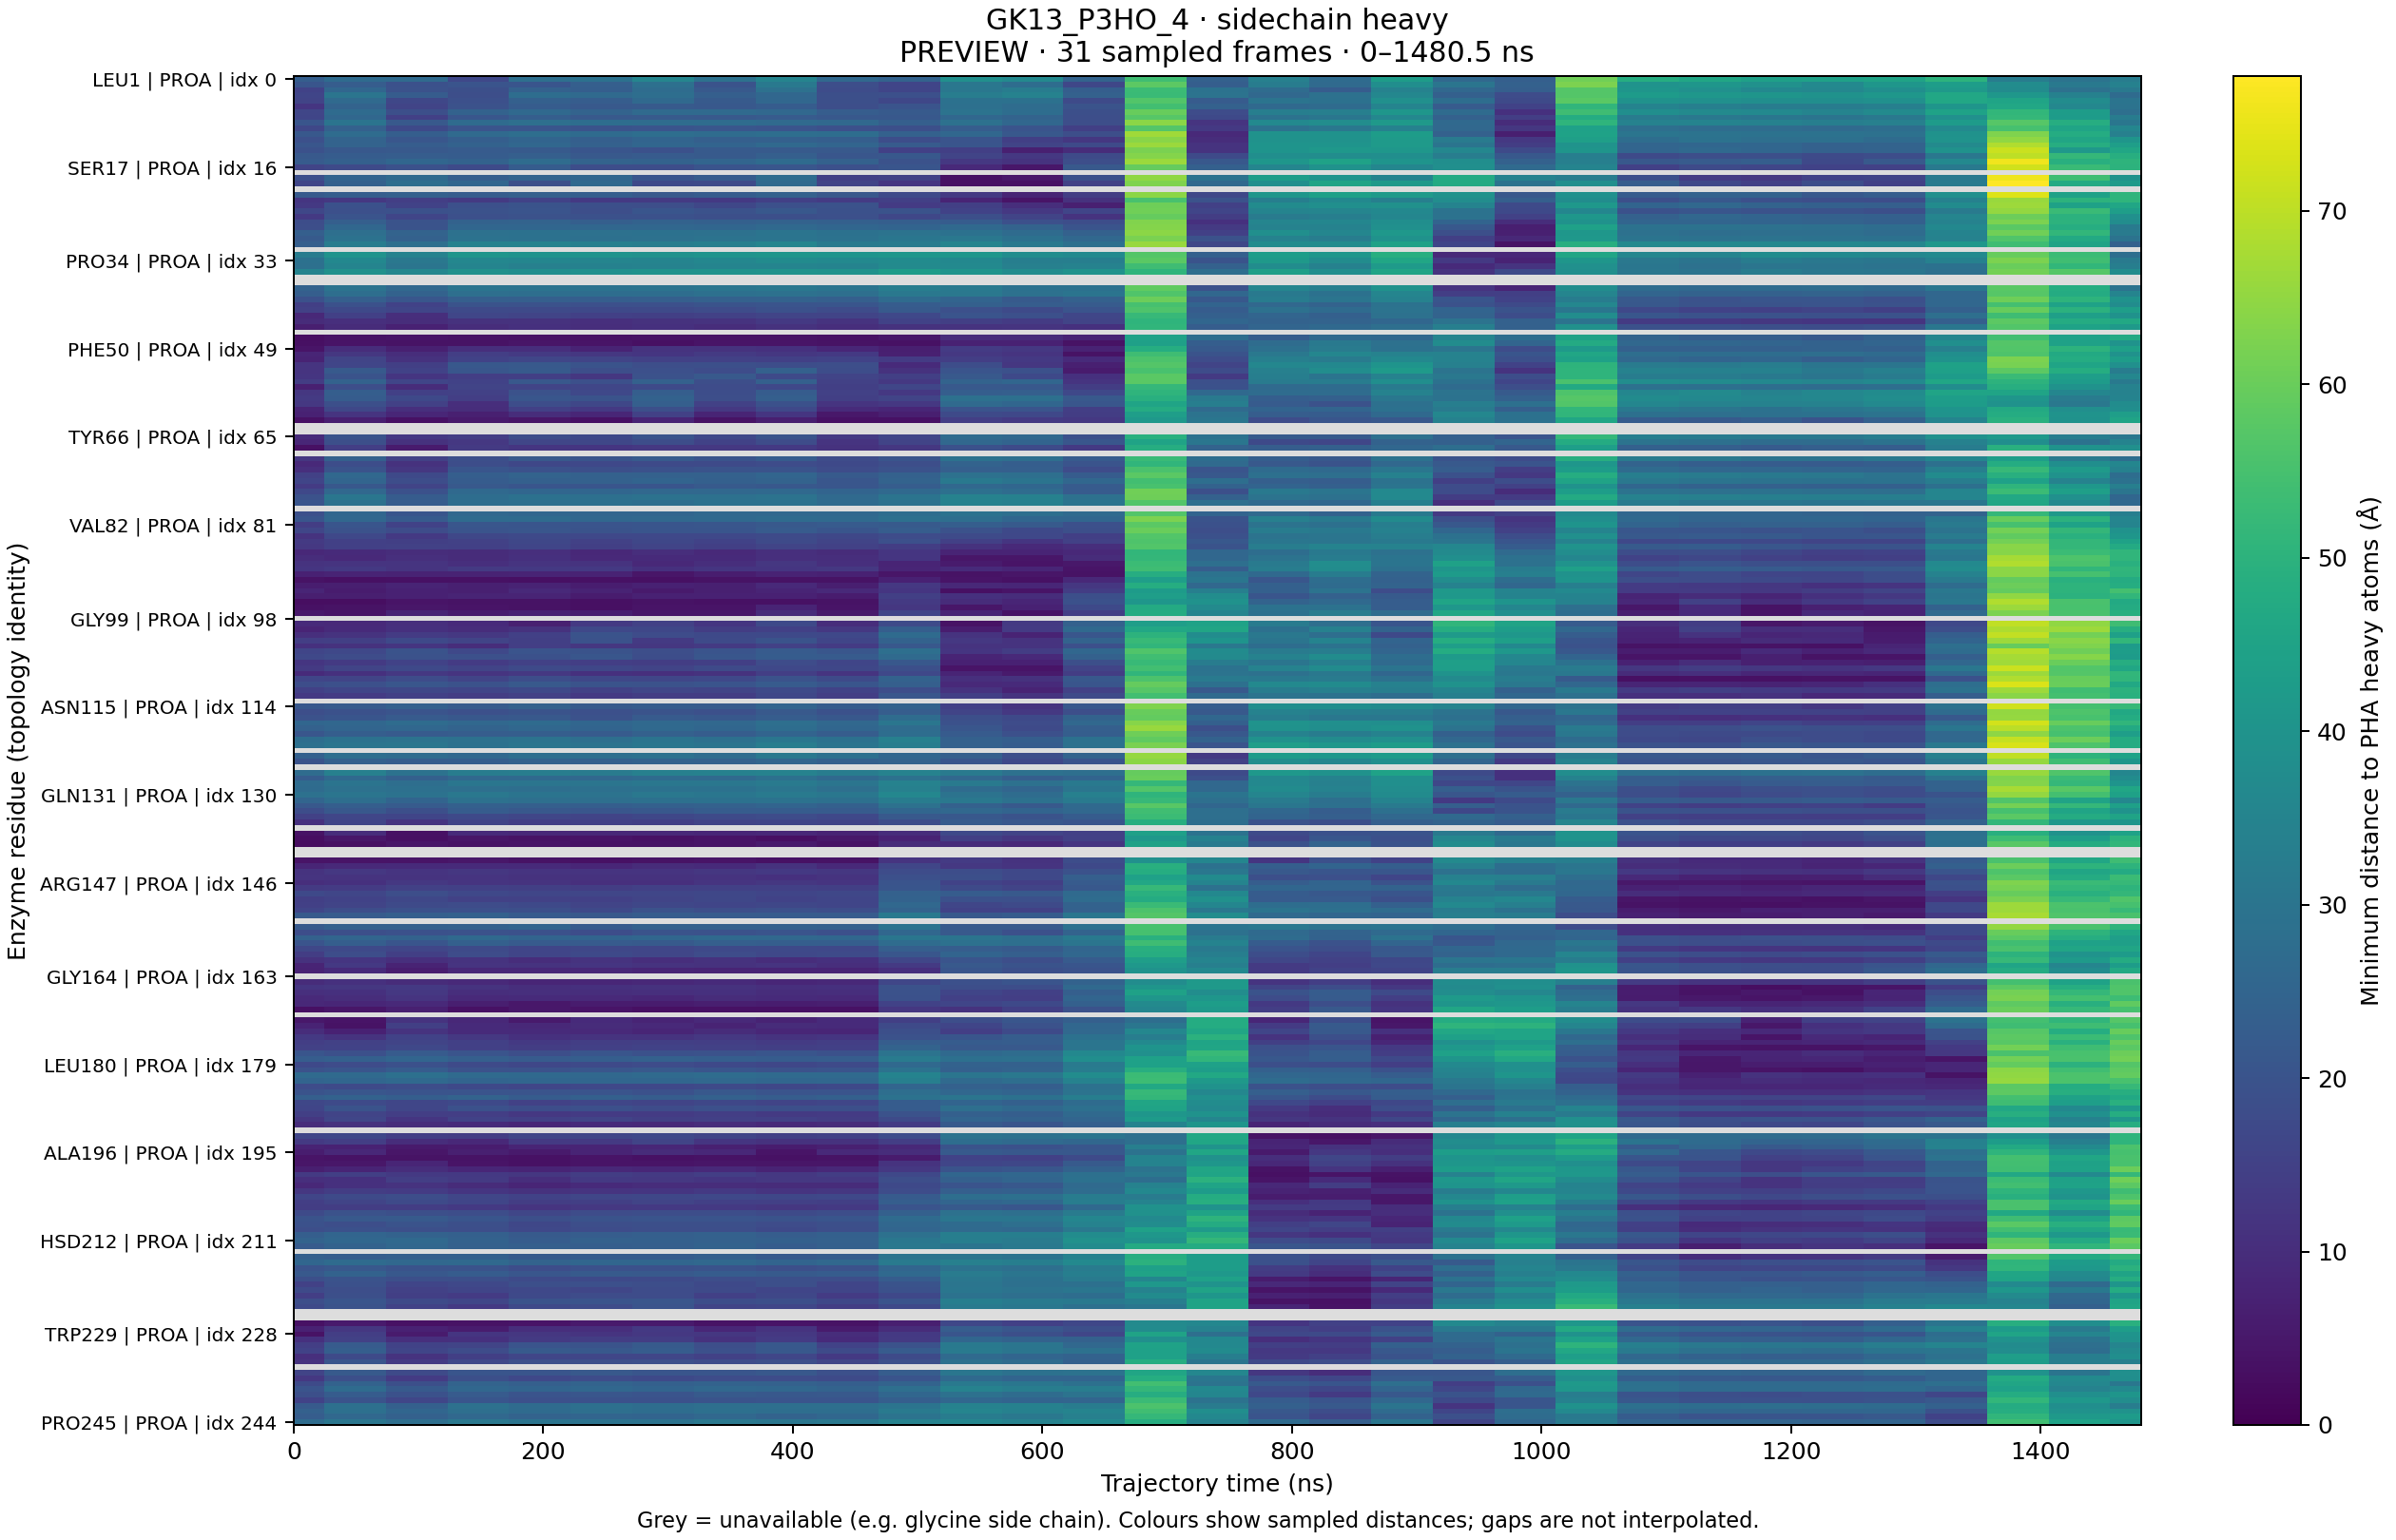

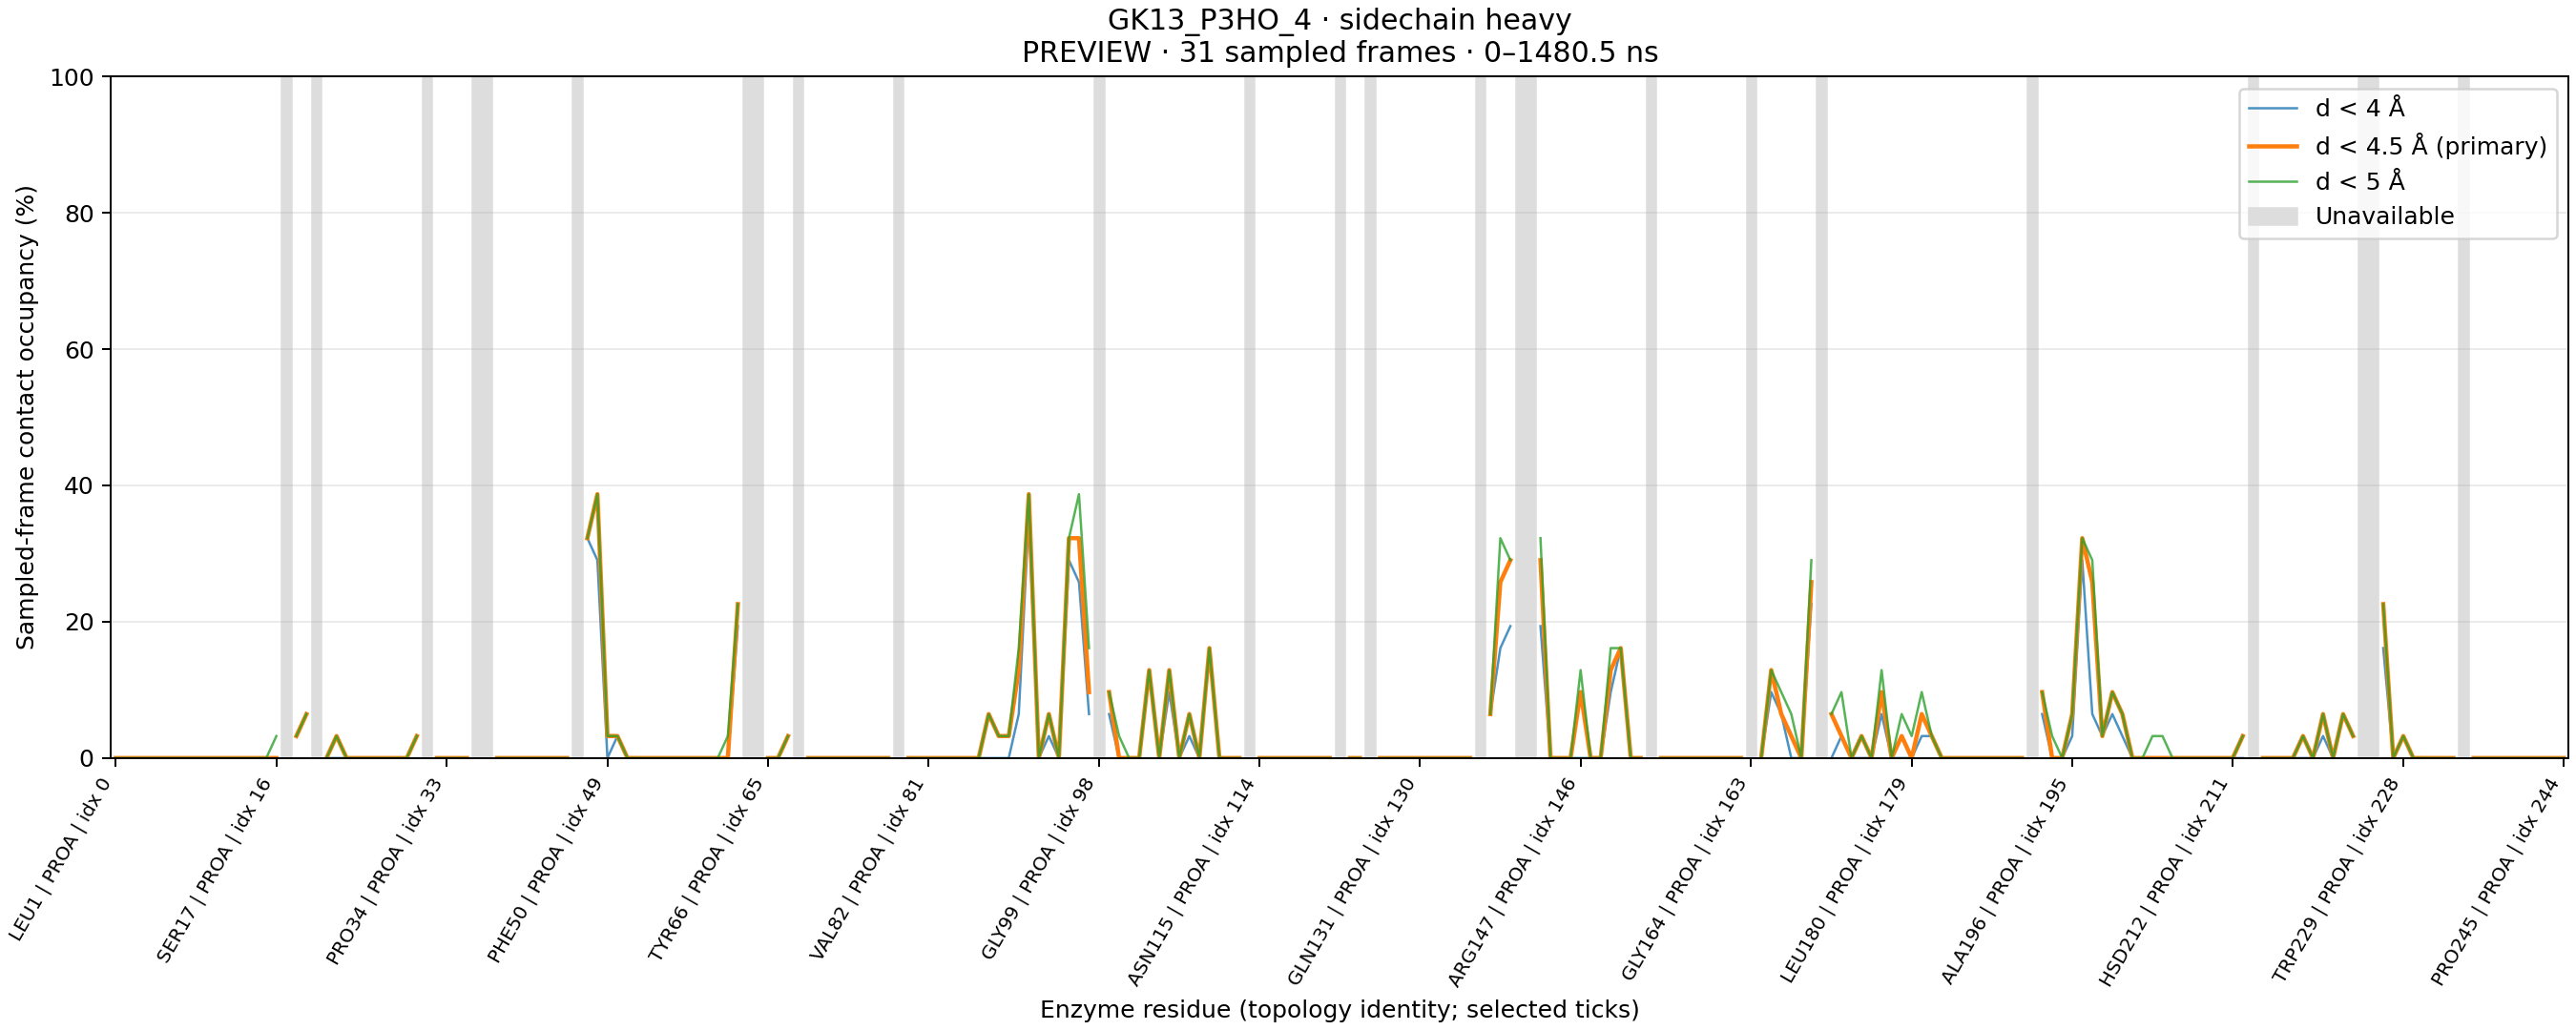

,Residue,Selected atoms,Mean distance (Å),Median distance (Å),Contact below 4.5 Å (%)
0,PHE92 | PROA | idx 91,7,18.87,17.05,38.71
1,PHE49 | PROA | idx 48,7,20.30,24.23,38.71
2,VAL197 | PROA | idx 196,3,19.47,15.41,32.26
3,ASN96 | PROA | idx 95,4,20.10,13.13,32.26
4,ILE97 | PROA | idx 96,4,18.67,7.76,32.26
5,SER48 | PROA | idx 47,2,19.89,22.53,32.26
6,SER140 | PROA | idx 139,2,18.79,14.29,29.03
7,TYR143 | PROA | idx 142,8,17.58,11.41,29.03
8,SER139 | PROA | idx 138,2,19.00,16.31,25.81
9,SER170 | PROA | idx 169,2,19.35,12.45,25.81


In [5]:
mode_labels = {
    "all_heavy": "All enzyme heavy atoms",
    "sidechain_heavy": "Enzyme side-chain heavy atoms",
}
summary = pd.read_csv(RUN_DIR / "residue_summary.csv")
occupancy_column = f"occupancy_lt_{config.primary_cutoff_A:g}_A_pct"
columns = ["label", "selected_atom_count", "mean_min_distance_A", "median_min_distance_A", occupancy_column]
column_labels = {
    "label": "Residue", "selected_atom_count": "Selected atoms",
    "mean_min_distance_A": "Mean distance (Å)",
    "median_min_distance_A": "Median distance (Å)",
    occupancy_column: f"Contact below {config.primary_cutoff_A:g} Å (%)",
}
for mode in config.modes:
    print(mode_labels[mode])
    display(Image(filename=str(RUN_DIR / f"distance_heatmap_{mode}.png")))
    display(Image(filename=str(RUN_DIR / f"contact_occupancy_{mode}.png")))
    top = (summary.loc[summary["mode"] == mode]
           .dropna(subset=[occupancy_column])
           .sort_values(occupancy_column, ascending=False)
           .head(10))
    display(top[columns].rename(columns=column_labels).round(2).reset_index(drop=True))

print("Plots:", RUN_DIR)
print("All residues:", RUN_DIR / "residue_summary.csv")
print("Saved distances:", RUN_DIR / "distances.npz")

## 6. Optional: reuse the saved distances
Change cutoffs without rereading the trajectory. After restarting the notebook, set `RUN_DIR` to an existing run folder before using this step.

To save revised plots, enable the second cell below. Its 15 Å colour limit affects only the display. A new subfolder keeps the original results intact. See the [guide](../docs/enzyme_contacts.md) for detailed methods and terminal usage.

In [6]:
# RUN_DIR = OUTPUT_DIR / "your_existing_run_folder"
saved = load_distances(RUN_DIR / "distances.npz")
NEW_CUTOFFS_A = (4.0, 4.5, 5.0, 6.0)
revised_summary = summarise(saved, NEW_CUTOFFS_A)
display(revised_summary.head())

,mode,resindex,resid,resname,segindex,segid,chain_ids,icode,label,selected_atom_count,n_analysed_frames,n_valid_frames,available,mean_min_distance_A,median_min_distance_A,occupancy_lt_4_A_pct,occupancy_lt_4.5_A_pct,occupancy_lt_5_A_pct,occupancy_lt_6_A_pct
0,all_heavy,0,1,LEU,0,seg_0_PROA,PROA,,LEU1 | PROA | idx 0,8,31,31,True,32.542645,30.542447,0.0,0.0,0.0,0.0
1,all_heavy,1,2,ARG,0,seg_0_PROA,PROA,,ARG2 | PROA | idx 1,11,31,31,True,29.948746,28.302942,0.0,0.0,0.0,0.0
2,all_heavy,2,3,PRO,0,seg_0_PROA,PROA,,PRO3 | PROA | idx 2,7,31,31,True,29.611267,28.384719,0.0,0.0,0.0,0.0
3,all_heavy,3,4,ALA,0,seg_0_PROA,PROA,,ALA4 | PROA | idx 3,5,31,31,True,29.337563,26.883836,0.0,0.0,0.0,0.0
4,all_heavy,4,5,GLU,0,seg_0_PROA,PROA,,GLU5 | PROA | idx 4,9,31,31,True,29.390077,28.135871,0.0,0.0,0.0,0.0


In [7]:
WRITE_REVISED_PLOTS = False
if WRITE_REVISED_PLOTS:
    from datetime import datetime, timezone
    derived_dir = RUN_DIR / ("replot_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ"))
    derived_dir.mkdir(exist_ok=False)
    revised_summary.to_csv(derived_dir / "residue_summary.csv", index=False, na_rep="NaN")
    plot_contacts(saved, derived_dir, NEW_CUTOFFS_A, primary_cutoff_A=PRIMARY_CUTOFF_A, distance_vmax_A=15)
    for mode in config.modes:
        display(Image(filename=str(derived_dir / f"distance_heatmap_{mode}.png")))
        display(Image(filename=str(derived_dir / f"contact_occupancy_{mode}.png")))
    print("Revised plots:", derived_dir)